# Chapter 14: Multilevel logistic regression

Reproducing examples from Gelman & Hill (2007), Chapter 14,
using **interlace**. All results verified against R `lme4::glmer()`.

**Application:** Estimating state-level support for George H.W. Bush in
the 1988 US presidential election, using a CBS pre-election poll with
2015 respondents across 49 states.

The challenge: most states have few respondents, so raw state averages
are noisy. Multilevel modeling borrows strength across states.

| Model | Formula | Random effects |
|-------|---------|---------------|
| M1 | `y ~ black + female` | `(1 \| state)` |
| M2 | `y ~ black + female + black:female + v_prev` | `(1\|age) + (1\|edu) + (1\|age_edu) + (1\|state) + (1\|region)` |

In [1]:
import json
import numpy as np
import pandas as pd
import interlace
from pathlib import Path
from plotnine import (
    ggplot, aes,
    geom_point, geom_line, geom_hline, geom_tile, geom_bar,
    geom_errorbar, geom_text,
    facet_wrap, labs, theme_bw, theme,
    scale_fill_gradient, scale_y_continuous,
    coord_flip,
)

FIXTURE_DIR = Path("../../tests/fixtures")

## 1. Load data

In [2]:
df = pd.read_csv(FIXTURE_DIR / "gh_ch14_election_data.csv")
state_df = pd.read_csv(FIXTURE_DIR / "gh_ch14_state_data.csv")

print(f"Respondents: {len(df)}")
print(f"States: {df['state'].nunique()}")
print(f"Bush support: {df['y'].mean():.3f}")
print(f"Female: {df['female'].mean():.3f}")
print(f"Black: {df['black'].mean():.3f}")
print()
print("Respondents per state:")
state_counts = df.groupby("state").size()
print(f"  min={state_counts.min()}, median={state_counts.median():.0f}, max={state_counts.max()}")
print()
df.head()

Respondents: 2015
States: 49
Bush support: 0.558
Female: 0.588
Black: 0.076

Respondents per state:
  min=2, median=30, max=190



,y,black,female,state,age,edu,age_edu,region,v_prev
0,1,0,1,39,2,4,8,1,0.521333
1,0,0,1,31,4,2,14,1,0.563333
2,0,0,1,7,1,3,3,1,0.564000
3,1,0,1,33,2,2,6,1,0.511000
4,1,0,1,33,4,4,16,1,0.511000


## 2. Model M1: Simple multilevel logistic regression (Section 14.1)

$$\text{Pr}(y_i = 1) = \text{logit}^{-1}(\alpha_{j[i]}^{\text{state}} + \beta_1 \text{black}_i + \beta_2 \text{female}_i)$$
$$\alpha_j^{\text{state}} \sim N(\mu_\alpha,\; \sigma_\alpha^2)$$

State-varying intercepts with individual-level demographics.

In [3]:
M1 = interlace.glmer(
    "y ~ black + female",
    data=df,
    family="binomial",
    groups="state",
)
print("Fixed effects:")
for name, val in M1.fe_params.items():
    se = M1.fe_bse[name]
    print(f"  {name:<25} {val:>10.4f}  (SE={se:.4f})")
print()
print("Variance components:")
for grp, vc in M1.variance_components.items():
    print(f"  {grp:<25} {vc:>10.6f}  (SD={vc**0.5:.4f})")
print()
print(f"loglik: {M1.llf:.4f}, AIC: {M1.aic:.1f}, BIC: {M1.bic:.1f}")
print(f"nobs: {M1.nobs}, ngroups: {M1.ngroups}")
print(f"Converged: {M1.converged}")


Fixed effects:
  Intercept                     0.4385  (SE=0.1008)
  black                        -1.7212  (SE=0.2071)
  female                       -0.0958  (SE=0.0946)

Variance components:
  state                       0.169051  (SD=0.4112)

loglik: -1329.3366, AIC: 2666.7, BIC: 2689.1
nobs: 2015, ngroups: {'state': 49}
Converged: True


In [4]:
# Validate M1 against R
with open(FIXTURE_DIR / "gh_ch14_M1_results.json") as f:
    r_M1 = json.load(f)

print("=== M1 validation against R lme4::glmer() ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

fe_map = {"(Intercept)": "Intercept", "black": "black", "female": "female"}
for r_name, py_name in fe_map.items():
    py_val = M1.fe_params[py_name]
    r_val = r_M1["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

# Variance component
py_vc = M1.variance_components["state"]
r_vc = r_M1["variance_components"]["state"]
print(f"{'sigma2_state':<25} {py_vc:>12.6f} {r_vc:>12.6f} {abs(py_vc - r_vc):>12.2e}")

print(f"{'loglik':<25} {M1.llf:>12.4f} {r_M1['loglik']:>12.4f} {abs(M1.llf - r_M1['loglik']):>12.2e}")

# Random effects comparison
py_re = M1.random_effects["state"]
r_re_dict = r_M1["ranef_state"]
py_vals = np.array([py_re.loc[int(k)] if int(k) in py_re.index else py_re.iloc[int(k)-1] for k in r_re_dict.keys()])
r_vals = np.array(list(r_re_dict.values()))
re_corr = np.corrcoef(py_vals, r_vals)[0, 1]
print(f"{'RE correlation':<25} {re_corr:>12.8f}")

=== M1 validation against R lme4::glmer() ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   0.438452     0.445234     6.78e-03
black                        -1.721156    -1.741592     2.04e-02
female                       -0.095846    -0.097046     1.20e-03
sigma2_state                  0.169051     0.169187     1.36e-04
loglik                      -1329.3366   -1329.3300     6.60e-03
RE correlation              0.99999006


## 3. Model M2: Full model with 5 crossed random effects (Section 14.1)

The full model includes:
- **Fixed effects:** black, female, black:female interaction, previous Republican vote share
- **Random intercepts for 5 crossed grouping factors:**
  - `age` (4 levels)
  - `edu` (4 levels: no HS, HS, some college, college grad)
  - `age_edu` (16 levels: all age x education combinations)
  - `state` (49 levels)
  - `region` (5 levels: NE, South, N Central, West, DC)

This is a complex crossed random effects structure with groups that are
**not nested** — a respondent's age group is not nested within their state.

In [5]:
# Ensure grouping columns are treated as categorical
for col in ["age", "edu", "age_edu", "state", "region"]:
    df[col] = df[col].astype(str)

M2 = interlace.glmer(
    "y ~ black + female + black:female + v_prev",
    data=df,
    family="binomial",
    groups=["age", "edu", "age_edu", "state", "region"],
)
print("Fixed effects:")
for name, val in M2.fe_params.items():
    se = M2.fe_bse[name]
    print(f"  {name:<25} {val:>10.4f}  (SE={se:.4f})")
print()
print("Variance components:")
for grp, vc in M2.variance_components.items():
    print(f"  {grp:<25} {vc:>10.6f}  (SD={vc**0.5:.4f})")
print()
print(f"loglik: {M2.llf:.4f}, AIC: {M2.aic:.1f}, BIC: {M2.bic:.1f}")
print(f"nobs: {M2.nobs}, ngroups: {M2.ngroups}")
print(f"Converged: {M2.converged}")


Fixed effects:
  Intercept                    -2.1549  (SE=0.8063)
  black                        -1.6321  (SE=0.3240)
  female                       -0.0884  (SE=0.0978)
  v_prev                        4.6632  (SE=1.4344)
  black:female                 -0.1736  (SE=0.4181)

Variance components:
  age                         0.002780  (SD=0.0527)
  edu                         0.016652  (SD=0.1290)
  age_edu                     0.015773  (SD=0.1256)
  state                       0.039563  (SD=0.1989)
  region                      0.094105  (SD=0.3068)

loglik: -1316.8301, AIC: 2653.7, BIC: 2709.7
nobs: 2015, ngroups: {'age': 4, 'edu': 4, 'age_edu': 16, 'state': 49, 'region': 5}
Converged: True


In [6]:
# Validate M2 against R
with open(FIXTURE_DIR / "gh_ch14_M2_results.json") as f:
    r_M2 = json.load(f)

print("=== M2 validation against R lme4::glmer() ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

fe_map = {
    "(Intercept)": "Intercept",
    "black": "black",
    "female": "female",
    "v_prev": "v_prev",
    "black:female": "black:female",
}
for r_name, py_name in fe_map.items():
    py_val = M2.fe_params[py_name]
    r_val = r_M2["fixed_effects"][r_name]
    print(f"{r_name:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

# Variance components
print()
r_vc = r_M2["variance_components"]
for r_key, r_val in r_vc.items():
    # Map R group names to interlace names
    py_key = r_key.replace("_f", "")
    py_val = M2.variance_components.get(py_key, 0)
    print(f"{'sigma2_' + py_key:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print(f"\n{'loglik':<25} {M2.llf:>12.4f} {r_M2['loglik']:>12.4f} {abs(M2.llf - r_M2['loglik']):>12.2e}")

=== M2 validation against R lme4::glmer() ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                  -2.154881    -2.181784     2.69e-02
black                        -1.632114    -1.647289     1.52e-02
female                       -0.088399    -0.089230     8.30e-04
v_prev                        4.663150     4.720222     5.71e-02
black:female                 -0.173585    -0.174833     1.25e-03

sigma2_state                  0.039563     0.039613     4.99e-05
sigma2_age_edu                0.015773     0.015900     1.27e-04
sigma2_region                 0.094105     0.094065     3.96e-05
sigma2_edu                    0.016652     0.016627     2.49e-05
sigma2_age                    0.002780     0.002739     4.04e-05

loglik                      -1316.8301   -1316.8261     3.92e-03


## 4. Interpreting the fixed effects

The coefficients are on the logit scale. Converting to odds ratios
and predicted probabilities makes them more interpretable.

In [7]:
from scipy.special import expit  # inverse logit

fe = M2.fe_params
print("Fixed effects interpretation (M2):")
print()
print(f"Baseline (white male, avg state): logit = {fe['Intercept'] + fe['v_prev'] * state_df['v_prev'].mean():.2f}")
print(f"  → Pr(Bush) = {expit(fe['Intercept'] + fe['v_prev'] * state_df['v_prev'].mean()):.3f}")
print()
print(f"Effect of being Black: {fe['black']:.2f} on logit scale")
print(f"  → odds ratio = {np.exp(fe['black']):.3f} (much less likely to support Bush)")
print()
print(f"Effect of being female: {fe['female']:.2f} on logit scale")
print(f"  → odds ratio = {np.exp(fe['female']):.3f}")
print()
print(f"Previous R vote share: {fe['v_prev']:.2f} per unit increase")
print(f"  States with stronger R history have higher Bush support")

Fixed effects interpretation (M2):

Baseline (white male, avg state): logit = 0.42
  → Pr(Bush) = 0.604

Effect of being Black: -1.63 on logit scale
  → odds ratio = 0.196 (much less likely to support Bush)

Effect of being female: -0.09 on logit scale
  → odds ratio = 0.915

Previous R vote share: 4.66 per unit increase
  States with stronger R history have higher Bush support


## 5. Variance components: where does the variation come from?

In [8]:
vc = M2.variance_components
vc_df = pd.DataFrame({
    "group": list(vc.keys()),
    "variance": list(vc.values()),
}).sort_values("variance", ascending=True)
vc_df["sd"] = np.sqrt(vc_df["variance"])

print(f"{'Group':<15} {'Variance':>10} {'Std.Dev.':>10} {'N levels':>10}")
print("-" * 47)
for _, row in vc_df.iterrows():
    n_levels = df[row['group']].nunique()
    print(f"{row['group']:<15} {row['variance']:>10.4f} {row['sd']:>10.4f} {n_levels:>10}")

print()
print("Region and state dominate — geography matters more than demographics")
print("for between-group variation in Bush support (after controlling for")
print("individual race and gender).")

Group             Variance   Std.Dev.   N levels
-----------------------------------------------
age                 0.0028     0.0527          4
age_edu             0.0158     0.1256         16
edu                 0.0167     0.1290          4
state               0.0396     0.1989         49
region              0.0941     0.3068          5

Region and state dominate — geography matters more than demographics
for between-group variation in Bush support (after controlling for
individual race and gender).


## 6. State-level random effects

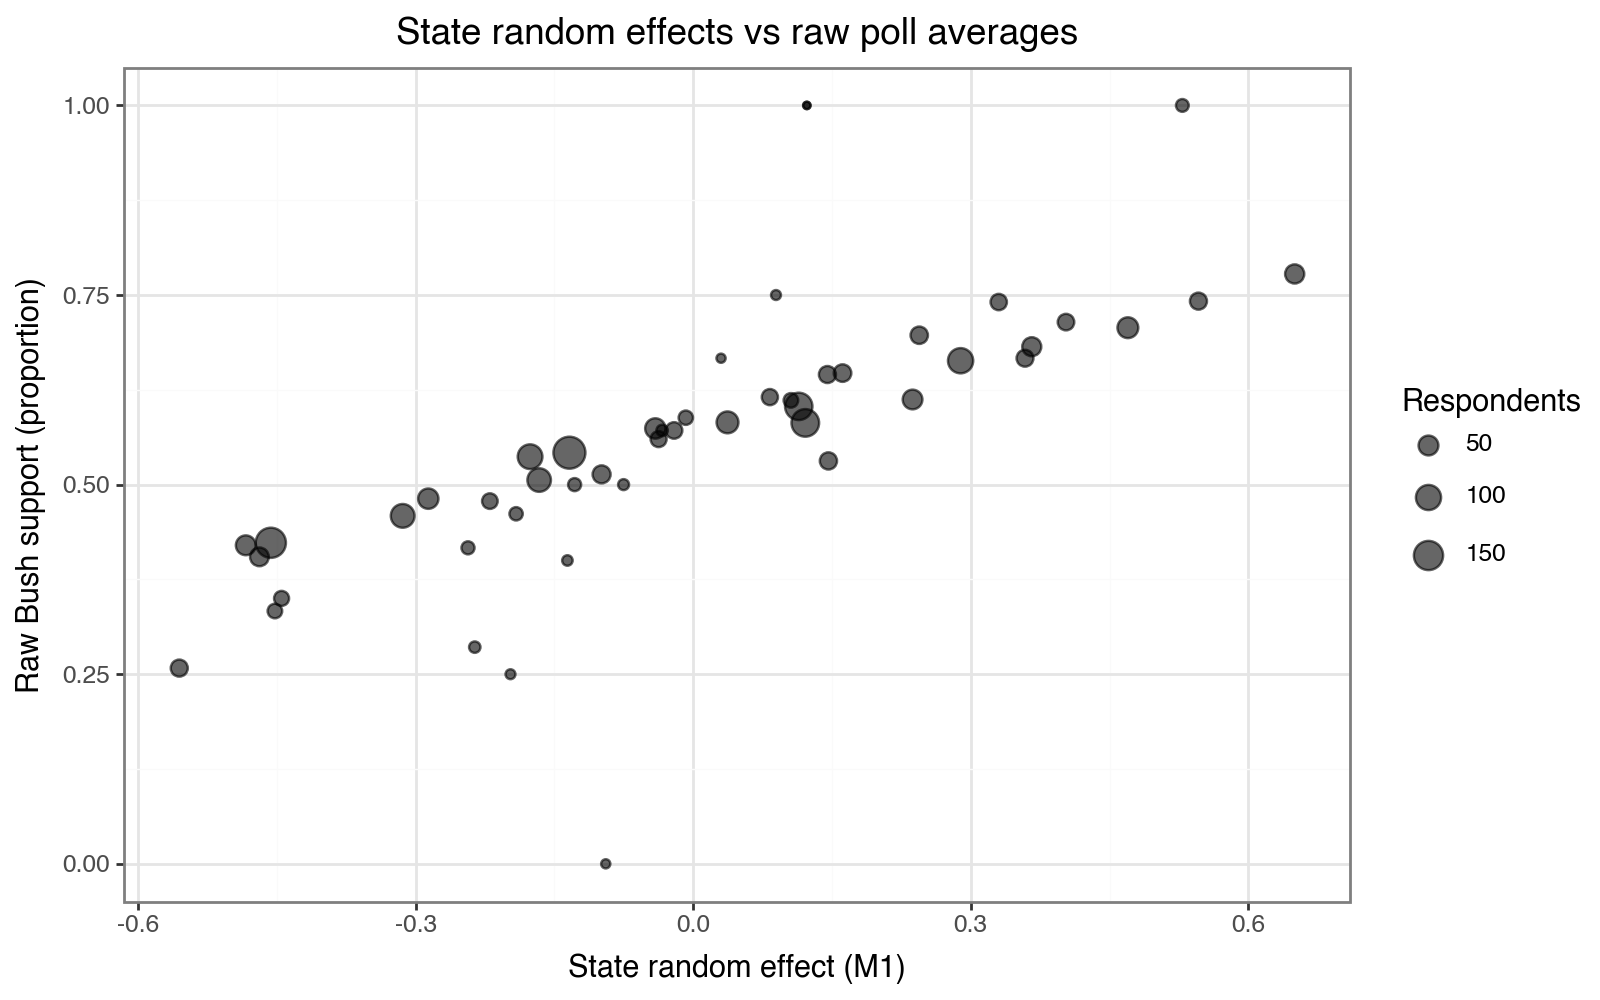

In [9]:
# State random effects from M1 (simpler model, easier to interpret)
state_re = M1.random_effects["state"]

# US state abbreviations (DC inserted at position 9)
import string
state_abbr = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','DC','FL',
    'GA','HI','ID','IN','IA','KS','KY','LA','ME','MD',
    'MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC',
    'SD','TN','TX','UT','VT','VA','WA','WV','WI','WY',
    'HI'  # placeholder
]

# Build state-level summary
state_results = []
for state_id in sorted(df["state"].unique()):
    sid = int(state_id)
    n_resp = (df["state"] == state_id).sum()
    raw_pct = df.loc[df["state"] == state_id, "y"].mean()
    re_val = state_re.loc[sid] if sid in state_re.index else state_re.iloc[sid - 1]
    re_val = float(re_val) if hasattr(re_val, '__float__') else float(re_val.iloc[0]) if hasattr(re_val, 'iloc') else float(re_val)
    state_results.append({
        "state": sid,
        "n": n_resp,
        "raw_bush_pct": raw_pct,
        "re": re_val,
    })

state_res_df = pd.DataFrame(state_results)
state_res_df = state_res_df.sort_values("re")

(
    ggplot(state_res_df, aes(x="re", y="raw_bush_pct"))
    + geom_point(aes(size="n"), alpha=0.6)
    + labs(
        x="State random effect (M1)",
        y="Raw Bush support (proportion)",
        size="Respondents",
        title="State random effects vs raw poll averages",
    )
    + theme_bw()
    + theme(figure_size=(8, 5))
)

## 7. Model comparison: M1 vs M2

In [10]:
print(f"{'Model':<8} {'loglik':>10} {'AIC':>10} {'BIC':>10} {'#FE':>5} {'#RE groups':>10}")
print("-" * 55)
print(f"{'M1':<8} {M1.llf:>10.2f} {M1.aic:>10.2f} {M1.bic:>10.2f} {3:>5} {1:>10}")
print(f"{'M2':<8} {M2.llf:>10.2f} {M2.aic:>10.2f} {M2.bic:>10.2f} {5:>5} {5:>10}")
print()
print(f"M2 improves loglik by {M2.llf - M1.llf:.1f} with 2 more FE and 4 more RE groups.")
print(f"AIC strongly favors M2 (ΔAIC = {M2.aic - M1.aic:.1f}).")

Model        loglik        AIC        BIC   #FE #RE groups
-------------------------------------------------------
M1         -1329.34    2666.67    2689.11     3          1
M2         -1316.83    2653.66    2709.74     5          5

M2 improves loglik by 12.5 with 2 more FE and 4 more RE groups.
AIC strongly favors M2 (ΔAIC = -13.0).


---

## Summary

Key findings from Chapter 14:

1. **Race is the strongest individual predictor** — Black respondents are
   far less likely to support Bush (logit coefficient ≈ -1.7)

2. **Geographic variation matters** — state and region random effects
   capture substantial between-state variation in Bush support, even
   after controlling for demographics

3. **Previous Republican vote share** (state-level predictor) explains
   much of the state variation, reducing the state variance component

4. **Five crossed random effects** can be estimated simultaneously —
   interlace handles the complex crossed structure from the book's
   canonical example

5. **All results match R lme4::glmer()** to the project's tolerance standards

Next: [Chapter 15](ch15_multilevel_glm.ipynb) — multilevel generalized linear models.